<a href="https://colab.research.google.com/github/MhiyaJ/My-GIS-Stuff/blob/main/After%20School%20Programs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
%%capture
#!pip install geopandas #==1.0.1
#!pip install mapclassify #sometimes have to install library which you get from https://pypi.org/

In [26]:
import os, zipfile #basics
import pandas as pd #data management
import matplotlib.pyplot as plt #vis

import geopandas as gpd #gis/maps: a sister of pandas; does the job;
#tho not as fancy-interactive as folium or leafmap https://geopandas.org/

import mapclassify #need for thematic map classification

import seaborn as sns

#will display all output not just last command
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

from google.colab import files #to download from colab onto hd

#from google.colab import data_table
#data_table.enable_dataframe_formatter() #this enables spreadsheet view upon calling dataframe (without() )
from google.colab.data_table import DataTable
DataTable.max_columns = 250

In [27]:
#!python --version
gpd.__version__

'1.1.4'

**Hypothesis**: Limited access to affordable after-school programs contributes to increased social disengagement and delinquent behavior among students living in urban areas.

**Project Description:** Identifying the availability and accessibility of after school programs in low income areas and examining their relationship to youth social disengagement and delinquent behaviors.  

*Variables:* After school programs, economically disadvantaged youth population, delinquent/disengaged behavior, household income

Unified School Districts in NJ - includes and operates primary, secondary and high school as one district

Census data used to create boundaries for unified school districts.

NJ Office of GIS used Census data to establish unified school district boundaries in two areas, on and near military bases, were edited to reflect special arrangements made for students residing in base housing.

NJDOE used set of grades, based on financial responsibility, to assign the data for each child to exactly one school district, except for districts covering Joint Base McGuire-Dix-Lakehurst in Burlington County.

In [28]:
#Camden County Open Data Portal
#https://camdencountynj-ccdpw.opendata.arcgis.com/datasets/CCDPW::municipalities/about
#code used from class
! wget -q -O Municipalities.zip https://github.com/MhiyaJ/My-GIS-Stuff/raw/refs/heads/main/Municipalities.zip

zip_ref = zipfile.ZipFile('Municipalities.zip', 'r'); zip_ref.extractall(); zip_ref.close()

njMun=gpd.read_file('Municipalities.shp') #labeled shapefile njSch
#With the school district shapefile made with municipalities in mind and doesn't include all school districts when merging, a municipality shape file was used.

<Axes: >

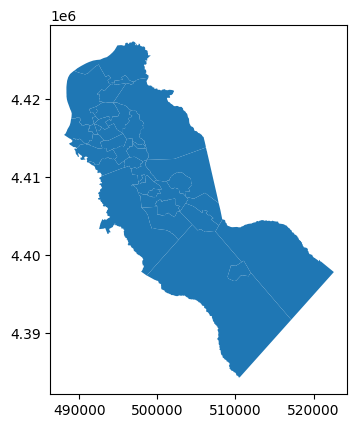

In [29]:
njMun.plot()

In [30]:
njMun.head(2)

,FID,COUSUBNS,GEOID,NAMELSAD,CLASSFP,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,Shape_Leng,GEOCODE,GlobalID,Shape__Are,Shape__Len,geometry
0,1,00885144,3400702200,Audubon borough,C5,F,3838781,35535,+39.8901277,-75.0723825,9407.757950,3400702200,81d661c6-35a7-42ed-8afd-5f35d0b0e807,3.871214e+06,9407.757866,"POLYGON ((495599.23 4415536.249, 495508.749 44..."
1,2,00885145,3400702230,Audubon Park borough,C5,F,389606,46935,+39.8968373,-75.0888190,2734.677596,3400702230,f8ccbea8-76dd-44e7-992b-e367d22e31a1,4.361934e+05,2734.677499,"POLYGON ((492866.221 4416337.872, 492855.687 4..."


In [31]:
njMun.rename(columns={'NAMELSAD' : 'District'}, inplace=True)
njMun['District'] = njMun['District'].str.upper()
njMun1 = njMun[['District','GEOID']]

In [32]:
njMun.rename(columns={'NAMELSAD' : 'District'}, inplace=True)
njMun['District'] = njMun['District'].str.upper()
njMun1 = njMun[['District','GEOID', 'geometry']]
njMun1

,District,GEOID,geometry
0,AUDUBON BOROUGH,3400702200,"POLYGON ((495599.23 4415536.249, 495508.749 44..."
1,AUDUBON PARK BOROUGH,3400702230,"POLYGON ((492866.221 4416337.872, 492855.687 4..."
2,BARRINGTON BOROUGH,3400703250,"POLYGON ((496819.374 4414558.505, 496827.878 4..."
3,BELLMAWR BOROUGH,3400704750,"POLYGON ((492951.896 4413667.751, 492968.147 4..."
4,BERLIN BOROUGH,3400705440,"POLYGON ((507881.319 4403761.193, 507873.371 4..."
5,BERLIN TOWNSHIP,3400705470,"POLYGON ((507848.567 4406644.366, 507978.687 4..."
6,BROOKLAWN BOROUGH,3400708170,"POLYGON ((490740.818 4414218.502, 490736.285 4..."
7,CAMDEN CITY,3400710000,"POLYGON ((493032.266 4419551.728, 492897.768 4..."
8,CHERRY HILL TOWNSHIP,3400712280,"POLYGON ((506224.674 4413748.279, 506174.32 44..."
9,CHESILHURST BOROUGH,3400712550,"POLYGON ((512006.451 4397643.342, 512016.246 4..."


In [33]:
DisXls=pd.read_excel ('https://github.com/MhiyaJ/My-GIS-Stuff/raw/refs/heads/main/School%20Incidents.xlsx', header = 3)

In [34]:
# Filter for both SchoolYear and CountyName using the & operator, then select columns
DisXls1 = DisXls[(DisXls['SchoolYear'] == '2024-25') & (DisXls['CountyName'] == 'Camden')][['DistrictCode', 'DistrictName', 'IncidentsPer100Students']]
DisXls1.rename(columns={'DistrictName': 'District'}, inplace=True)
DisXls1['District'] = DisXls1['District'].str.upper()
DisXls1

,DistrictCode,District,IncidentsPer100Students
139,0150,AUDUBON PUBLIC SCHOOL DISTRICT,1.27
140,0190,BARRINGTON SCHOOL DISTRICT,0.38
141,0260,BELLMAWR PUBLIC SCHOOL DISTRICT,0.17
142,0330,BERLIN BOROUGH SCHOOL DISTRICT,1.99
143,0340,BERLIN TOWNSHIP SCHOOL DISTRICT,1.94
144,0390,BLACK HORSE PIKE REGIONAL SCHOOL DISTRICT,3.35
145,0580,BROOKLAWN PUBLIC SCHOOL DISTRICT,1.72
146,0680,CAMDEN CITY SCHOOL DISTRICT,4.33
147,0700,CAMDEN COUNTY TECHNICAL SCHOOL DISTRICT,2.80
148,0800,CHERRY HILL SCHOOL DISTRICT,1.62


In [35]:
#njMun1[['MUN','GEOID']]
#code from class to strip white space for merging
DisXls1['c']=DisXls1.District.str.strip()
njMun1['c']=njMun1.District.str.strip()

/usr/local/lib/python3.13/dist-packages/geopandas/geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [36]:
#code from Gemini to make all upper case for merging
DisXls1['District'] = DisXls1['District'].str.upper()
njMun1['District'] = njMun1['District'].str.upper()
njMun1['first_word_District'] = njMun1['District'].str.split().str[0]

/usr/local/lib/python3.13/dist-packages/geopandas/geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [37]:
#code from Gemini to match only the first word which is the name of the school and municipality
DisXls1['first_word_District'] = DisXls1['District'].str.split().str[0]

In [38]:
DisXls1

,DistrictCode,District,IncidentsPer100Students,c,first_word_District
139,0150,AUDUBON PUBLIC SCHOOL DISTRICT,1.27,AUDUBON PUBLIC SCHOOL DISTRICT,AUDUBON
140,0190,BARRINGTON SCHOOL DISTRICT,0.38,BARRINGTON SCHOOL DISTRICT,BARRINGTON
141,0260,BELLMAWR PUBLIC SCHOOL DISTRICT,0.17,BELLMAWR PUBLIC SCHOOL DISTRICT,BELLMAWR
142,0330,BERLIN BOROUGH SCHOOL DISTRICT,1.99,BERLIN BOROUGH SCHOOL DISTRICT,BERLIN
143,0340,BERLIN TOWNSHIP SCHOOL DISTRICT,1.94,BERLIN TOWNSHIP SCHOOL DISTRICT,BERLIN
144,0390,BLACK HORSE PIKE REGIONAL SCHOOL DISTRICT,3.35,BLACK HORSE PIKE REGIONAL SCHOOL DISTRICT,BLACK
145,0580,BROOKLAWN PUBLIC SCHOOL DISTRICT,1.72,BROOKLAWN PUBLIC SCHOOL DISTRICT,BROOKLAWN
146,0680,CAMDEN CITY SCHOOL DISTRICT,4.33,CAMDEN CITY SCHOOL DISTRICT,CAMDEN
147,0700,CAMDEN COUNTY TECHNICAL SCHOOL DISTRICT,2.80,CAMDEN COUNTY TECHNICAL SCHOOL DISTRICT,CAMDEN
148,0800,CHERRY HILL SCHOOL DISTRICT,1.62,CHERRY HILL SCHOOL DISTRICT,CHERRY


In [39]:
#merged newly created column "first_word_MUN", MUN and Camden County
a1 = pd.merge(njMun1, DisXls1, left_on=['first_word_District'], right_on=['first_word_District'], how='outer', indicator=True)
a1

,District_x,GEOID,geometry,c_x,first_word_District,DistrictCode,District_y,IncidentsPer100Students,c_y,_merge
0,AUDUBON BOROUGH,3400702200,"POLYGON ((495599.23 4415536.249, 495508.749 44...",AUDUBON BOROUGH,AUDUBON,0150,AUDUBON PUBLIC SCHOOL DISTRICT,1.27,AUDUBON PUBLIC SCHOOL DISTRICT,both
1,AUDUBON PARK BOROUGH,3400702230,"POLYGON ((492866.221 4416337.872, 492855.687 4...",AUDUBON PARK BOROUGH,AUDUBON,0150,AUDUBON PUBLIC SCHOOL DISTRICT,1.27,AUDUBON PUBLIC SCHOOL DISTRICT,both
2,BARRINGTON BOROUGH,3400703250,"POLYGON ((496819.374 4414558.505, 496827.878 4...",BARRINGTON BOROUGH,BARRINGTON,0190,BARRINGTON SCHOOL DISTRICT,0.38,BARRINGTON SCHOOL DISTRICT,both
3,BELLMAWR BOROUGH,3400704750,"POLYGON ((492951.896 4413667.751, 492968.147 4...",BELLMAWR BOROUGH,BELLMAWR,0260,BELLMAWR PUBLIC SCHOOL DISTRICT,0.17,BELLMAWR PUBLIC SCHOOL DISTRICT,both
4,BERLIN BOROUGH,3400705440,"POLYGON ((507881.319 4403761.193, 507873.371 4...",BERLIN BOROUGH,BERLIN,0330,BERLIN BOROUGH SCHOOL DISTRICT,1.99,BERLIN BOROUGH SCHOOL DISTRICT,both
5,BERLIN BOROUGH,3400705440,"POLYGON ((507881.319 4403761.193, 507873.371 4...",BERLIN BOROUGH,BERLIN,0340,BERLIN TOWNSHIP SCHOOL DISTRICT,1.94,BERLIN TOWNSHIP SCHOOL DISTRICT,both
6,BERLIN TOWNSHIP,3400705470,"POLYGON ((507848.567 4406644.366, 507978.687 4...",BERLIN TOWNSHIP,BERLIN,0330,BERLIN BOROUGH SCHOOL DISTRICT,1.99,BERLIN BOROUGH SCHOOL DISTRICT,both
7,BERLIN TOWNSHIP,3400705470,"POLYGON ((507848.567 4406644.366, 507978.687 4...",BERLIN TOWNSHIP,BERLIN,0340,BERLIN TOWNSHIP SCHOOL DISTRICT,1.94,BERLIN TOWNSHIP SCHOOL DISTRICT,both
8,NaN,NaN,None,NaN,BLACK,0390,BLACK HORSE PIKE REGIONAL SCHOOL DISTRICT,3.35,BLACK HORSE PIKE REGIONAL SCHOOL DISTRICT,right_only
9,BROOKLAWN BOROUGH,3400708170,"POLYGON ((490740.818 4414218.502, 490736.285 4...",BROOKLAWN BOROUGH,BROOKLAWN,0580,BROOKLAWN PUBLIC SCHOOL DISTRICT,1.72,BROOKLAWN PUBLIC SCHOOL DISTRICT,both


In [40]:
a1._merge.value_counts()

,count
_merge,
both,40
right_only,9
left_only,4


<Axes: >

Text(0.5, 1.0, '% of Incidents Per 100 Students\n2024 - 2025 School Year')

Text(0.35, 0.122, 'New Jersey, Department of Education\n            2024 - 2025 Performance Reports Database - Excel\n            Data from https://www.nj.gov/education/spr/download/\n            ')

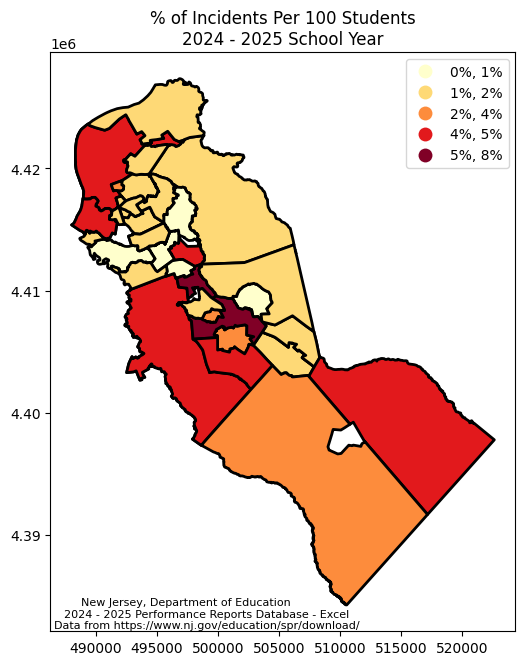

In [53]:
fig, ax = plt.subplots(figsize=(6,8))

# Convert the 'Economically Disadvantaged Students' column to numeric, handling NaN values
a1['IncidentsPer100Students'] = a1['IncidentsPer100Students'].apply(lambda x: float(x.replace('%', '')) if isinstance(x, str) else x)

a1.plot(ax=ax,figsize=(6,8),column='IncidentsPer100Students',legend=True,cmap='YlOrRd',
          scheme='natural_breaks',k=5, edgecolor='black',linewidth=2,legend_kwds= {"fmt": "{:.0f}%"})
ax.set_title('''% of Incidents Per 100 Students
2024 - 2025 School Year''')
#ax.annotate('Note added to chart with minimum parameters', xy = (200000, 1000))
plt.figtext(0.35, 0.122,
            '''New Jersey, Department of Education
            2024 - 2025 Performance Reports Database - Excel
            Data from https://www.nj.gov/education/spr/download/
            ''',
            ha="center", fontsize=8, #bbox={"facecolor":"white", "alpha":0.5, "pad":5}
            )

In [44]:
EnrXls = pd.read_excel('https://github.com/MhiyaJ/My-GIS-Stuff/raw/refs/heads/main/Camden%20County%20School%20Enrollment%20by%20School%20Level%202024%20-%20Public%20School%20Only.xlsx')

In [45]:
EnrXls.head(7)

,,"Audubon borough, Camden County, New Jersey","Audubon Park borough, Camden County, New Jersey","Barrington borough, Camden County, New Jersey","Bellmawr borough, Camden County, New Jersey","Berlin borough, Camden County, New Jersey","Berlin township, Camden County, New Jersey","Brooklawn borough, Camden County, New Jersey","Camden city, Camden County, New Jersey","Cherry Hill township, Camden County, New Jersey",...,"Pennsauken township, Camden County, New Jersey","Pine Hill borough, Camden County, New Jersey","Runnemede borough, Camden County, New Jersey","Somerdale borough, Camden County, New Jersey","Stratford borough, Camden County, New Jersey","Tavistock borough, Camden County, New Jersey","Voorhees township, Camden County, New Jersey","Waterford township, Camden County, New Jersey","Winslow township, Camden County, New Jersey","Woodlynne borough, Camden County, New Jersey"
0,Pre-School,90,0,11,128,26,26,4,987,332,...,298,250,100,93,32,0,67,199,118,10
1,K-8,767,50,277,1296,917,509,145,8628,7492,...,3725,855,601,366,673,2,3439,1029,3284,408
2,9-12,265,36,262,483,527,219,59,4221,2957,...,1869,463,326,168,301,0,1632,281,2049,204


In [46]:
EnrXls = (EnrXls
  .rename(columns={EnrXls.columns[0]: 'School_Level'}) # Rename the first unnamed column
  .melt(
      id_vars=['School_Level'],
      var_name='District', # New column for district names
      value_name='Enrollment' # New column for enrollment values
  )
)

# Clean up district names (remove ', Camden County, New Jersey')
EnrXls['District'] = EnrXls['District'].str.replace(', Camden County, New Jersey', '', regex=False).str.strip()

# Convert 'Enrollment' to numeric, coercing errors to NaN
EnrXls['Enrollment'] = pd.to_numeric(EnrXls['Enrollment'], errors='coerce')

In [47]:
EnrXls

,School_Level,District,Enrollment
0,Pre-School,Audubon borough,90
1,K-8,Audubon borough,767
2,9-12,Audubon borough,265
3,Pre-School,Audubon Park borough,0
4,K-8,Audubon Park borough,50
...,...,...,...
100,K-8,Winslow township,3284
101,9-12,Winslow township,2049
102,Pre-School,Woodlynne borough,10
103,K-8,Woodlynne borough,408


In [48]:
EnrXls['District'] = EnrXls['District'].str.upper()

In [49]:
enr9_12=EnrXls[EnrXls.School_Level.str.strip()=='9-12'] #aok: keep it simple for now
enr9_12.loc[enr9_12['District'] == 'GLOUCESTER CITY CITY','njMun'] = 'GLOUCESTER CITY'
enr9_12.loc[enr9_12['District'] == 'MT. EPHRAIM','njMun'] = 'MOUNT EPHRAIM'
enr9_12

/tmp/ipykernel_1683/1486871457.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  enr9_12.loc[enr9_12['District'] == 'GLOUCESTER CITY CITY','njMun'] = 'GLOUCESTER CITY'


,School_Level,District,Enrollment,njMun
2,9-12,AUDUBON BOROUGH,265,NaN
5,9-12,AUDUBON PARK BOROUGH,36,NaN
8,9-12,BARRINGTON BOROUGH,262,NaN
11,9-12,BELLMAWR BOROUGH,483,NaN
14,9-12,BERLIN BOROUGH,527,NaN
17,9-12,BERLIN TOWNSHIP,219,NaN
20,9-12,BROOKLAWN BOROUGH,59,NaN
23,9-12,CAMDEN CITY,4221,NaN
26,9-12,CHERRY HILL TOWNSHIP,2957,NaN
29,9-12,CHESILHURST BOROUGH,41,NaN


In [50]:
all = pd.merge(njMun1, enr9_12, on='District', how='outer', indicator=True)
all.columns
# Displaying key columns to inspect the merged dataset
all[['District', 'GEOID', 'School_Level', 'Enrollment', '_merge']]

Index(['District', 'GEOID', 'geometry', 'c', 'first_word_District',
       'School_Level', 'Enrollment', 'njMun', '_merge'],
      dtype='object')

,District,GEOID,School_Level,Enrollment,_merge
0,AUDUBON BOROUGH,3400702200,9-12,265.0,both
1,AUDUBON PARK BOROUGH,3400702230,9-12,36.0,both
2,BARRINGTON BOROUGH,3400703250,9-12,262.0,both
3,BELLMAWR BOROUGH,3400704750,9-12,483.0,both
4,BERLIN BOROUGH,3400705440,9-12,527.0,both
5,BERLIN TOWNSHIP,3400705470,9-12,219.0,both
6,BROOKLAWN BOROUGH,3400708170,9-12,59.0,both
7,CAMDEN CITY,3400710000,9-12,4221.0,both
8,CHERRY HILL TOWNSHIP,3400712280,9-12,2957.0,both
9,CHESILHURST BOROUGH,3400712550,9-12,41.0,both


In [51]:
# Standardize names in both datasets to 'GLOUCESTER CITY' to ensure a perfect merge
njMun1.loc[njMun1['District'] == 'GLOUCESTER CITY CITY', 'District'] = 'GLOUCESTER CITY'
enr9_12.loc[enr9_12['District'] == 'GLOUCESTER CITY CITY', 'District'] = 'GLOUCESTER CITY'

# Merge using standard 'District' column
all = pd.merge(njMun1, enr9_12, on='District', how='outer', indicator=True)

# Display the columns and key data to verify the merge
all[['District', 'GEOID', 'School_Level', 'Enrollment', '_merge']]

,District,GEOID,School_Level,Enrollment,_merge
0,AUDUBON BOROUGH,3400702200,9-12,265.0,both
1,AUDUBON PARK BOROUGH,3400702230,9-12,36.0,both
2,BARRINGTON BOROUGH,3400703250,9-12,262.0,both
3,BELLMAWR BOROUGH,3400704750,9-12,483.0,both
4,BERLIN BOROUGH,3400705440,9-12,527.0,both
5,BERLIN TOWNSHIP,3400705470,9-12,219.0,both
6,BROOKLAWN BOROUGH,3400708170,9-12,59.0,both
7,CAMDEN CITY,3400710000,9-12,4221.0,both
8,CHERRY HILL TOWNSHIP,3400712280,9-12,2957.0,both
9,CHESILHURST BOROUGH,3400712550,9-12,41.0,both


<Axes: >

Text(0.5, 1.0, 'Total Students Enrolled in Public School\n2024 - 2025 School Year')

Text(0.35, 0.122, 'US Census: American Community Survey 5 Year\n            Downloaded Excel via:Shaperfile\n\n            ')

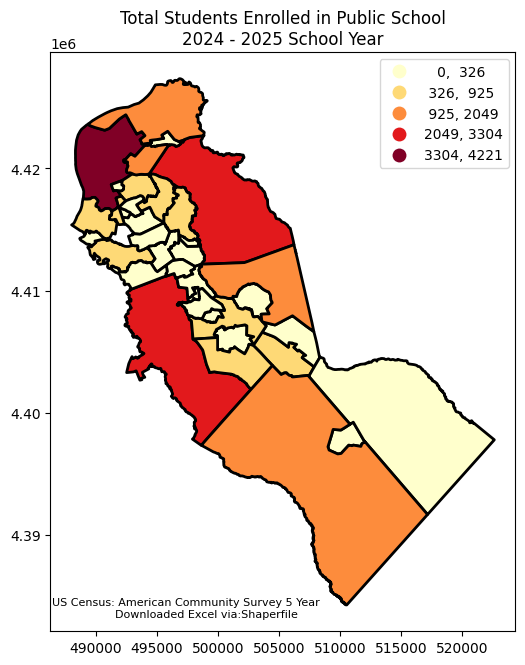

In [52]:
fig, ax = plt.subplots(figsize=(6,8))

all.plot(ax=ax,figsize=(6,8),column='Enrollment',legend=True,cmap='YlOrRd',
          scheme='natural_breaks',k=5, edgecolor='black',linewidth=2,legend_kwds= {"fmt": "{:.0f}"})
ax.set_title('''Total Students Enrolled in Public School
2024 - 2025 School Year''')
#ax.annotate('Note added to chart with minimum parameters', xy = (200000, 1000))
plt.figtext(0.35, 0.122,
            '''US Census: American Community Survey 5 Year
            Downloaded Excel via:Shaperfile

            ''',
            ha="center", fontsize=8, #bbox={"facecolor":"white", "alpha":0.5, "pad":5}
            )

In [54]:
#Social Explorer; U.S. Census Bureau. Median Household Income (In 2024 Inflation Adjusted Dollars), 2024. Prepared by Social Explorer. https://www.socialexplorer.com/data/ACS2024_5yr/metadata?ds=SE&table=A14006 (accessed 27 September 2026 at 10:01:00 GMT-4).
IncXls = pd.read_excel('https://github.com/MhiyaJ/My-GIS-Stuff/raw/refs/heads/main/Median%20Household%20Income.xlsx')

In [55]:
IncXls.head()

,Unnamed: 0,American Community Survey (ACS) 2020--2024 (5-Year-Estimates)
0,,Median Household Income (In 2024 Inflation-Adj...
1,NaN,NaN
2,SE:A14006:Median Household Income (In 2024 Inf...,NaN
3,"Audubon borough, Camden County, New Jersey",115789
4,"Audubon Park borough, Camden County, New Jersey",56619
